In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pandas as pd

df_ts = pd.read_excel('TimeSeries.xlsx')
df_ts

,Year,Month,Sales
0,2005.0,1,10827
1,NaN,2,12049
2,NaN,3,18298
3,NaN,4,17834
4,NaN,5,16480
...,...,...,...
148,NaN,5,31739
149,NaN,6,30315
150,NaN,7,25046
151,NaN,8,23285


In [ ]:
df_ts.describe()

,Year,Month,Sales
count,13.00000,153.000000,153.000000
mean,2011.00000,6.411765,20284.915033
std,3.89444,3.436509,6370.759660
min,2005.00000,1.000000,7709.000000
25%,2008.00000,3.000000,16662.000000
50%,2011.00000,6.000000,18955.000000
75%,2014.00000,9.000000,23006.000000
max,2017.00000,12.000000,45061.000000


In [ ]:
df_ts['Sales'].describe()


count      153.000000
mean     20284.915033
std       6370.759660
min       7709.000000
25%      16662.000000
50%      18955.000000
75%      23006.000000
max      45061.000000
Name: Sales, dtype: float64

In [ ]:
df_ts['Sales'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 153 entries, 0 to 152
Series name: Sales
Non-Null Count  Dtype
--------------  -----
153 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB


In [ ]:
# Converting year and month columns into a single date column
df_ts['Year'] = df_ts['Year'].fillna(method='ffill').astype(int)
df_ts['Month'] = df_ts['Month'].astype(int)

# Creating a mapping for month names
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

# Create the new column with month and year
df_ts['MonthYear'] = df_ts.apply(lambda row: f"{month_names.get(row['Month'])} {row['Year']}", axis=1)

In [ ]:
df_ts.head(20)

,Year,Month,Sales,MonthYear
0,2005,1,10827,Jan 2005
1,2005,2,12049,Feb 2005
2,2005,3,18298,Mar 2005
3,2005,4,17834,Apr 2005
4,2005,5,16480,May 2005
5,2005,6,16690,Jun 2005
6,2005,7,15389,Jul 2005
7,2005,8,13031,Aug 2005
8,2005,9,17849,Sep 2005
9,2005,10,16662,Oct 2005


In [ ]:
df_ts.drop(['Year','Month'], axis = 1, inplace=True)

In [ ]:
df_ts = df_ts[['MonthYear', 'Sales']]
df_ts

,MonthYear,Sales
0,Jan 2005,10827
1,Feb 2005,12049
2,Mar 2005,18298
3,Apr 2005,17834
4,May 2005,16480
...,...,...
148,May 2017,31739
149,Jun 2017,30315
150,Jul 2017,25046
151,Aug 2017,23285


In [ ]:
df_ts.to_csv('SalesData.csv', index=False)

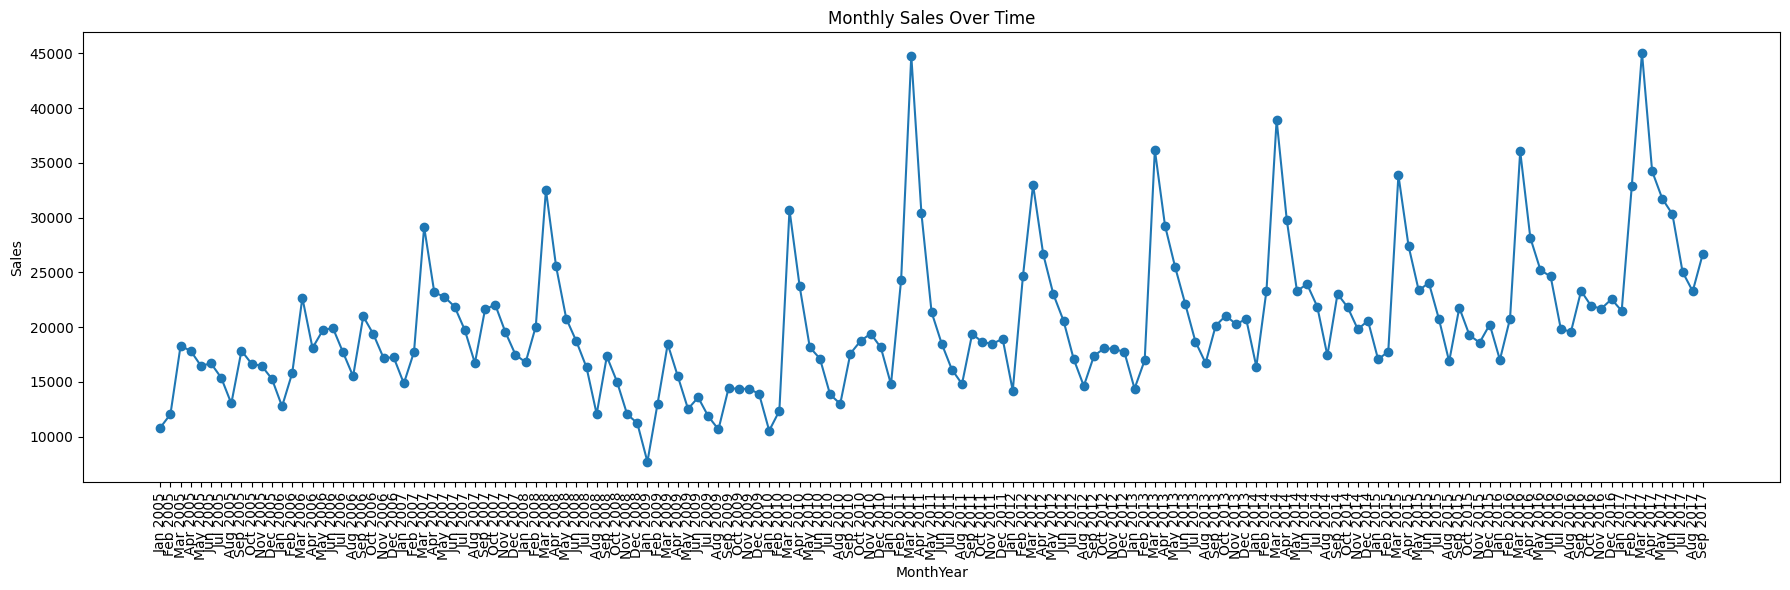

In [ ]:
# Create a line plot of sales data
plt.figure(figsize=(18, 6))  # Adjust the figure size as needed
plt.plot(df_ts['MonthYear'], df_ts['Sales'], marker='o', linestyle='-')

# Add labels and title
plt.xlabel('MonthYear')
plt.ylabel('Sales')
plt.title('Monthly Sales Over Time')

# Rotate x-axis labels for readability (optional)
plt.xticks(rotation=90)

# Show the plot
plt.grid(False)
plt.tight_layout()
plt.show()

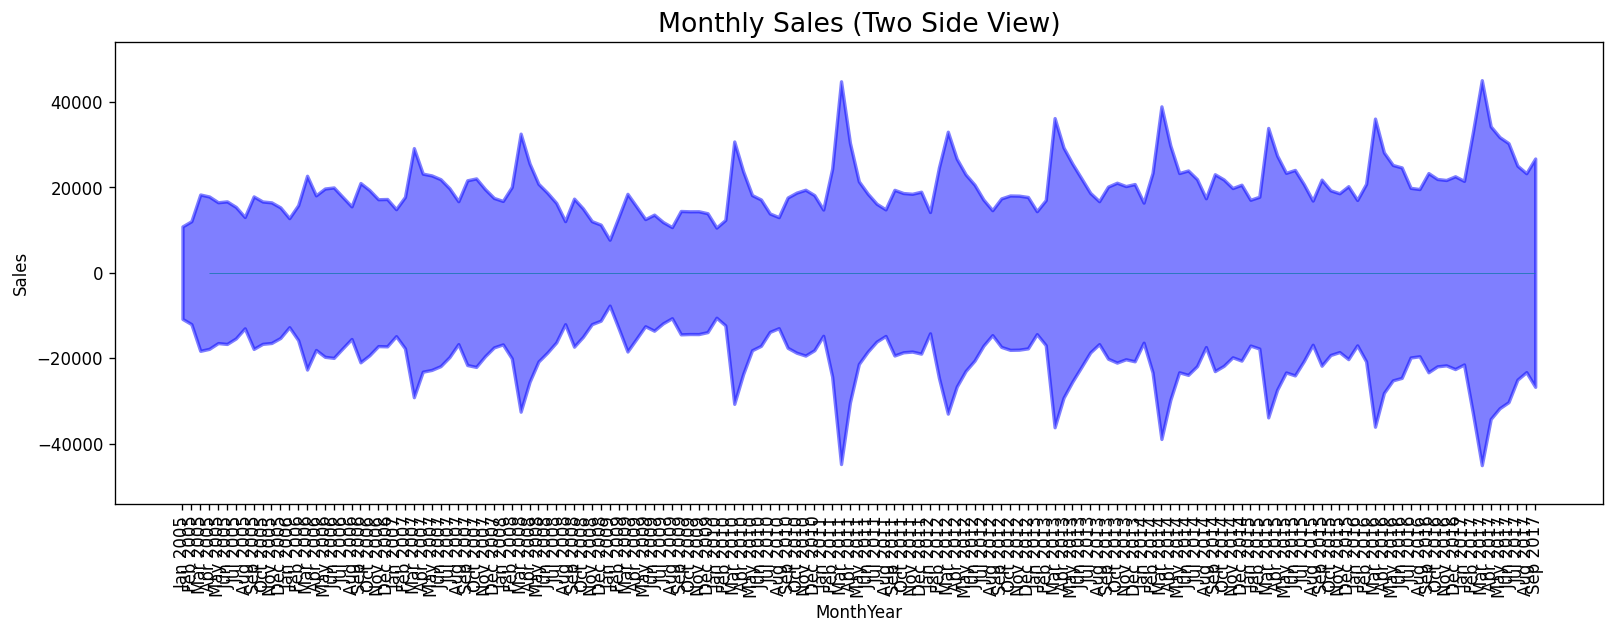

In [ ]:
#better way to visualize trend by mirroring
x = df_ts['MonthYear']  # Assuming the index is your datetime column
y1 = df_ts['Sales'].values  # Replace 'Sales' with the actual column name

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 5), dpi=120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='blue')
plt.ylim(-max(y1) * 1.2, max(y1) * 1.2)  # Adjust the y-axis limits based on your data
plt.title('Monthly Sales (Two Side View)', fontsize=16)  # Modify the title as needed
plt.hlines(y=0, xmin=np.min(x), xmax=np.max(x), linewidth=0.5)
plt.xlabel('MonthYear')  # Add x-axis label if needed
plt.ylabel('Sales')  # Add y-axis label if needed
plt.xticks(rotation=90)

plt.grid(False)

plt.show()


<Figure size 1600x1200 with 0 Axes>

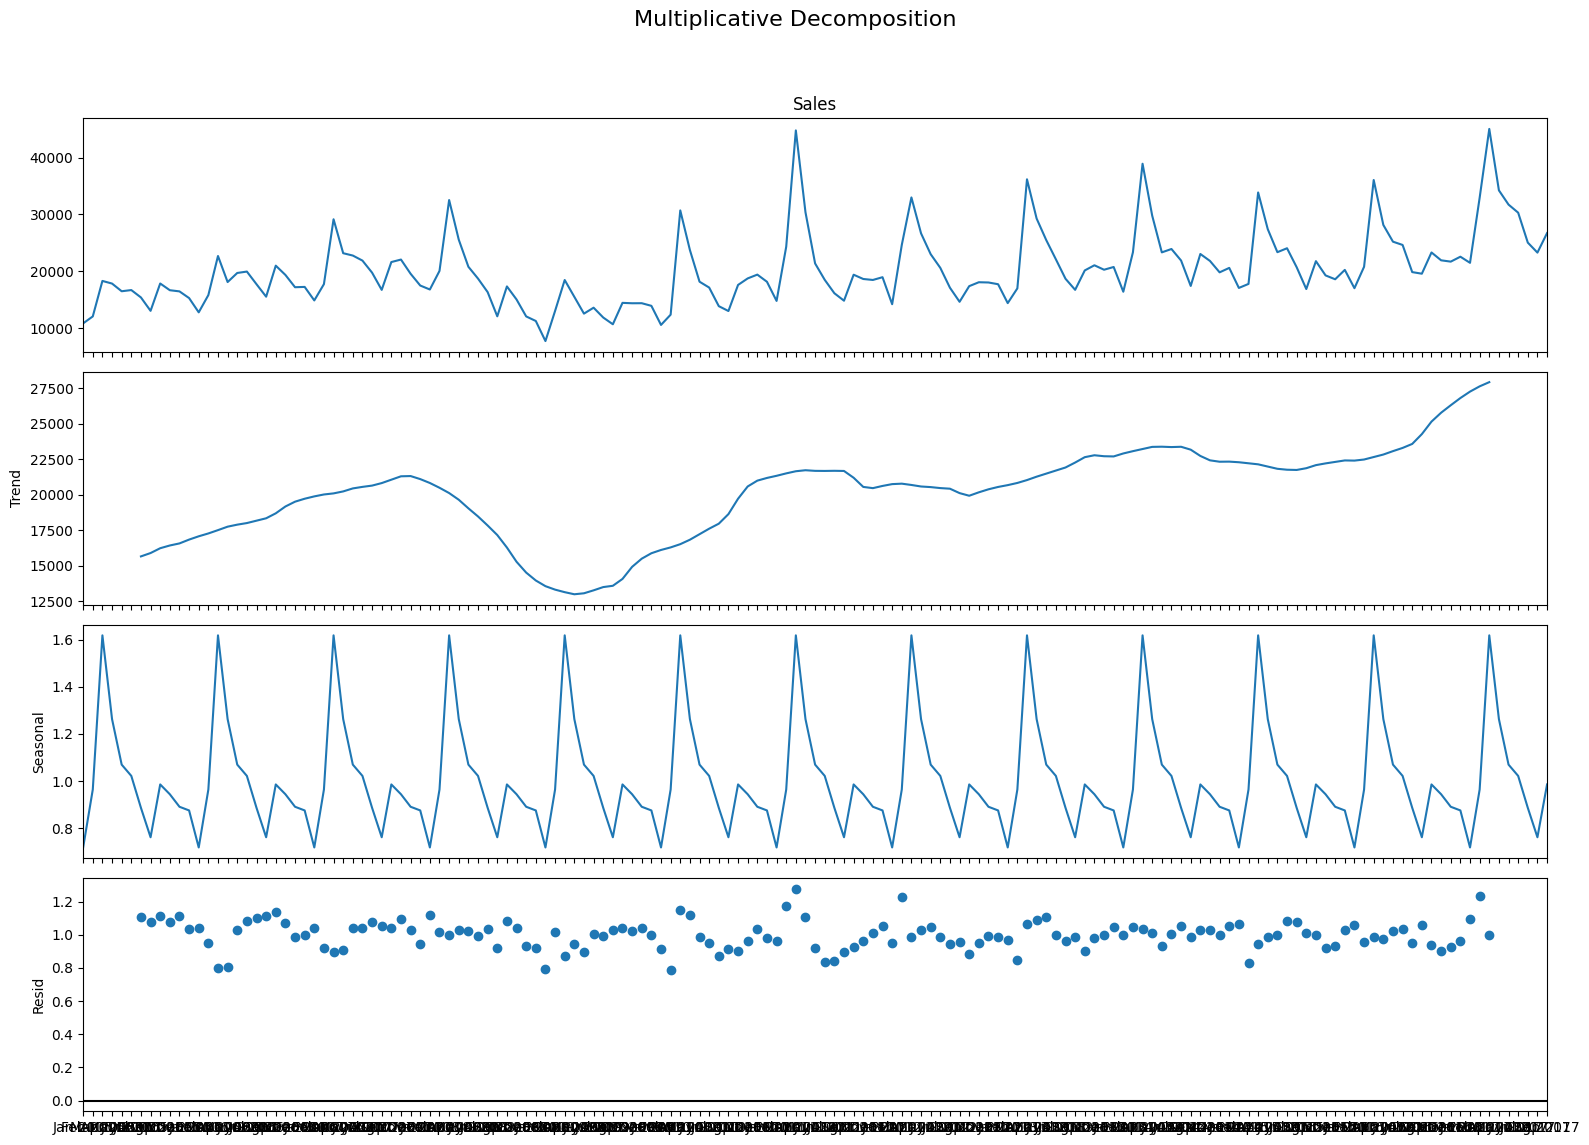

<Figure size 1600x1200 with 0 Axes>

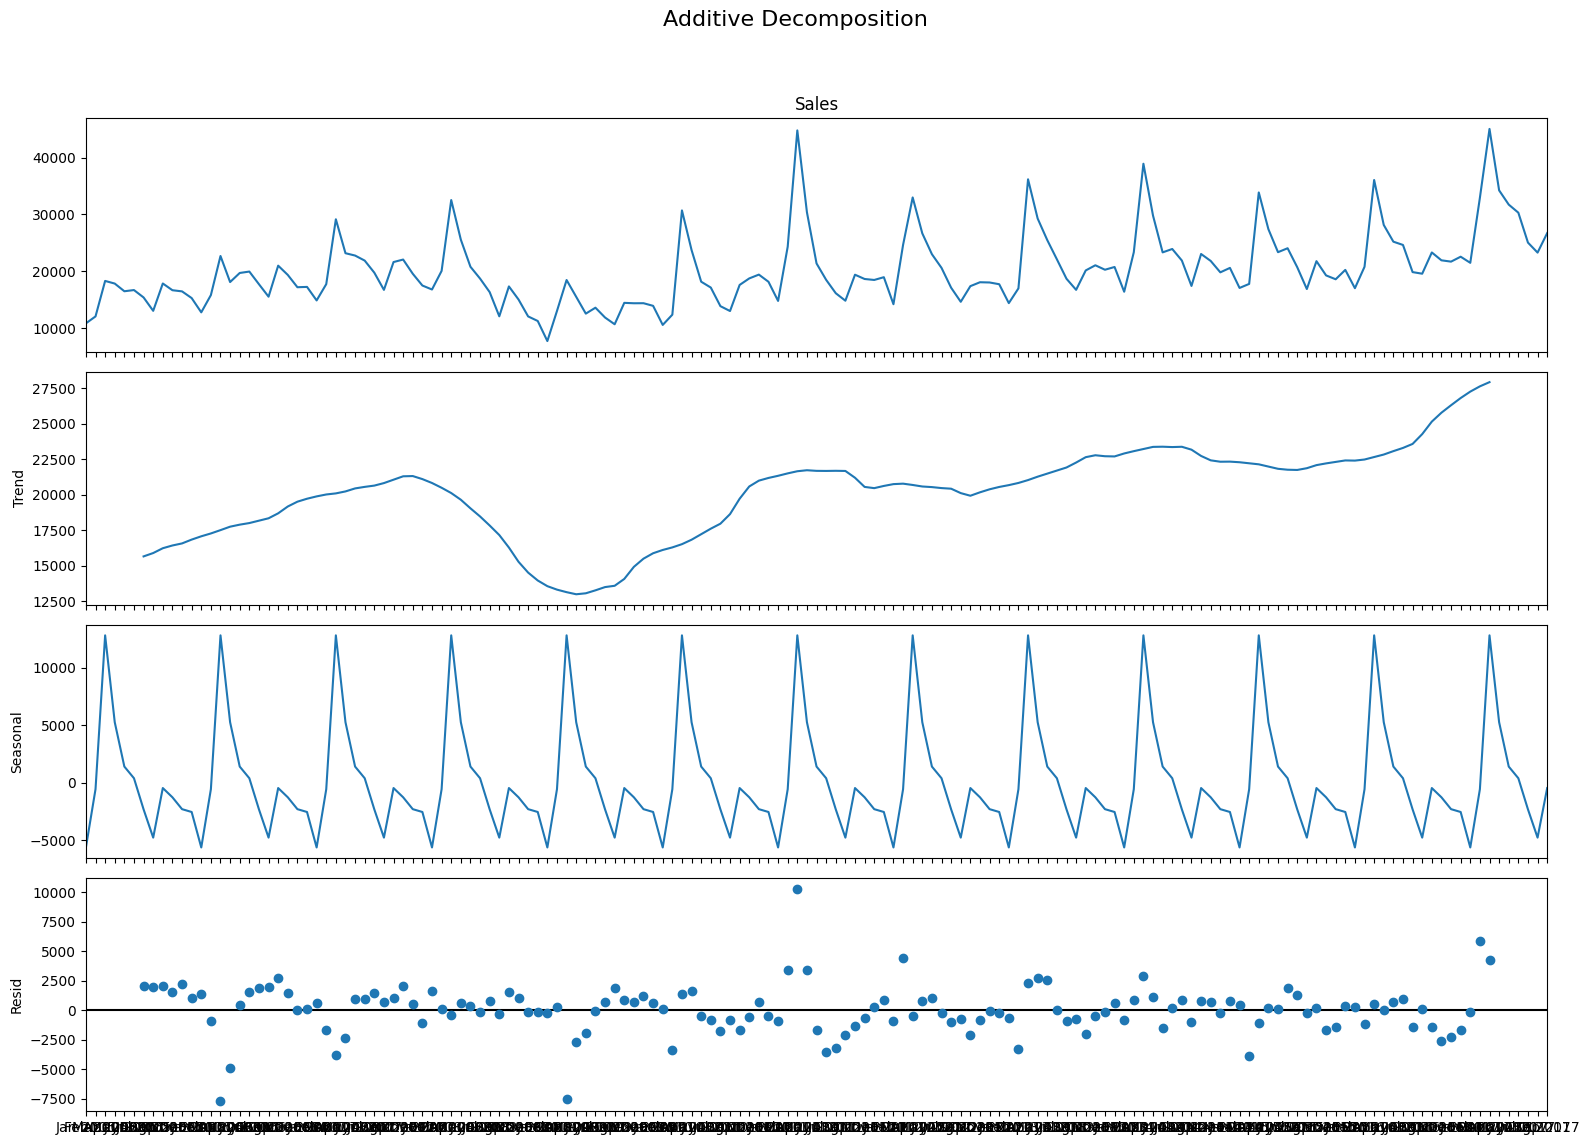

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Specify the frequency of your time series (e.g., 12 for monthly data)
frequency = 12

# Multiplicative Decomposition
multiplicative_decomposition = seasonal_decompose(df_ts['Sales'], model='multiplicative', period=frequency)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df_ts['Sales'], model='additive', period=frequency)

# Plotting the Multiplicative Decomposition
plt.rcParams.update({'figure.figsize': (16, 12)})
plt.figure()
multiplicative_decomposition.plot()
plt.suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Plotting the Additive Decomposition
plt.figure()
additive_decomposition.plot()
plt.suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


# **Checking Stationarity with Augmented Dickey-Fuller Test**

In [ ]:
from statsmodels.tsa.stattools import adfuller

Sales_df = df_ts['Sales']

result = adfuller(Sales_df)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

# Interpret the results
if p_value < 0.05:
    print('The time series is likely stationary (reject the null hypothesis).')
else:
    print('The time series is likely non-stationary (fail to reject the null hypothesis).')


ADF Statistic: -1.2852168563620374
p-value: 0.6359081904491788
Critical Values:
   1%: -3.4782936965183815
   5%: -2.882567574015525
   10%: -2.5779830117488745
The time series is likely non-stationary (fail to reject the null hypothesis).


In [ ]:
print(result)

(-1.2852168563620374, 0.6359081904491788, 13, 139, {'1%': -3.4782936965183815, '5%': -2.882567574015525, '10%': -2.5779830117488745}, 2599.0790937347256)


# Stationarising the time series

In [ ]:
!pip install statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

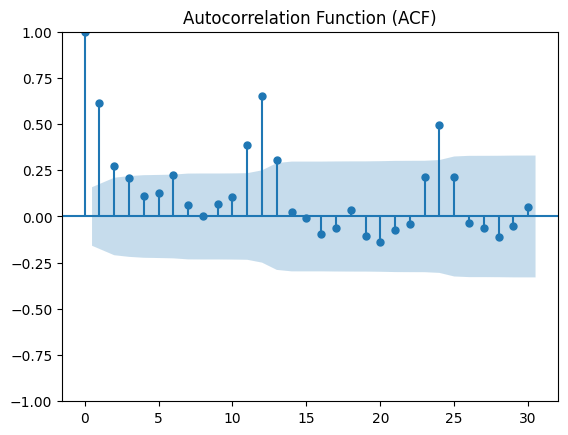

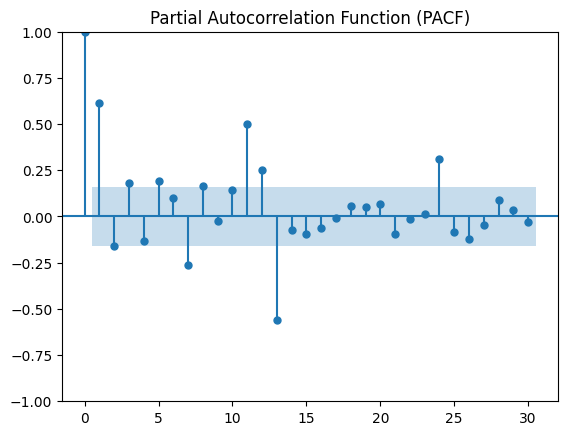

In [ ]:
#stationarity can aslo be visually examined by plotting ACF and PACF

# Plot ACF
plot_acf(df_ts['Sales'], lags = 30)
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plot_pacf(df_ts['Sales'], lags = 30)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()


<ipython-input-9-680bf56d2e14>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Sales_log'] = df_ts['Sales'].apply(np.log)


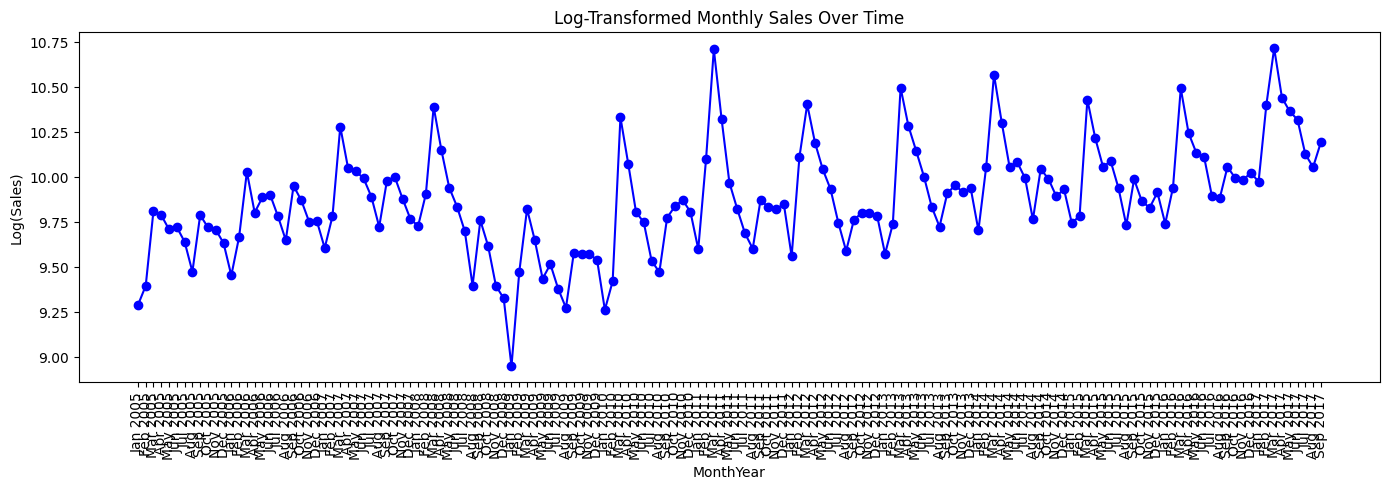

In [ ]:
# Apply a log transformation to the original sales data
df_ts['Sales_log'] = df_ts['Sales'].apply(np.log)

# Create a line plot of the log-transformed original sales data
plt.figure(figsize=(14, 5))
plt.plot(df_ts['MonthYear'], df_ts['Sales_log'], marker='o', linestyle='-', color='b')

# Customize the x-axis labels
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('MonthYear')
plt.ylabel('Log(Sales)')
plt.title('Log-Transformed Monthly Sales Over Time')

# Show the plot
plt.grid(False)
plt.tight_layout()
plt.show()

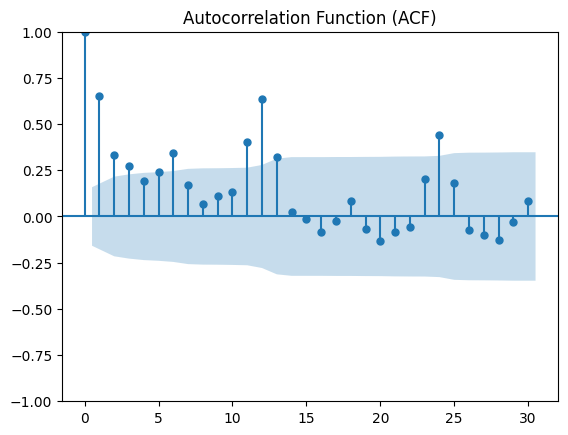

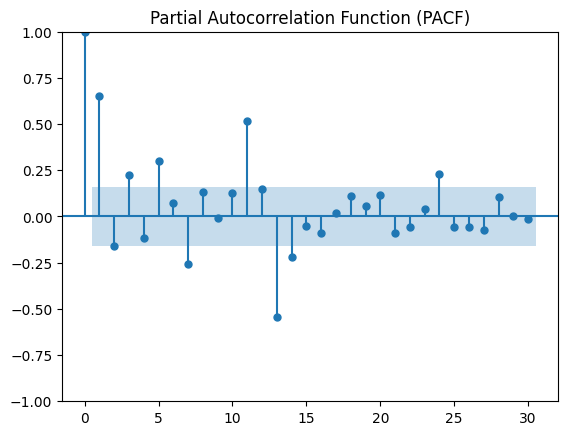

In [ ]:
plot_acf(df_ts['Sales_log'], lags = 30)
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plot_pacf(df_ts['Sales_log'], lags = 30)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [ ]:
#now perform first order differencing to stablise mean

df_ts['Sales_log_diff'] = df_ts['Sales_log'] - df_ts['Sales_log'].shift(1)

# Removing missing values created by differencing
df_ts['Sales_log_diff'].dropna(inplace=True)

<ipython-input-10-745017625c1e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Sales_log_diff'] = df_ts['Sales_log'] - df_ts['Sales_log'].shift(1)
<ipython-input-10-745017625c1e>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Sales_log_diff'].dropna(inplace=True)


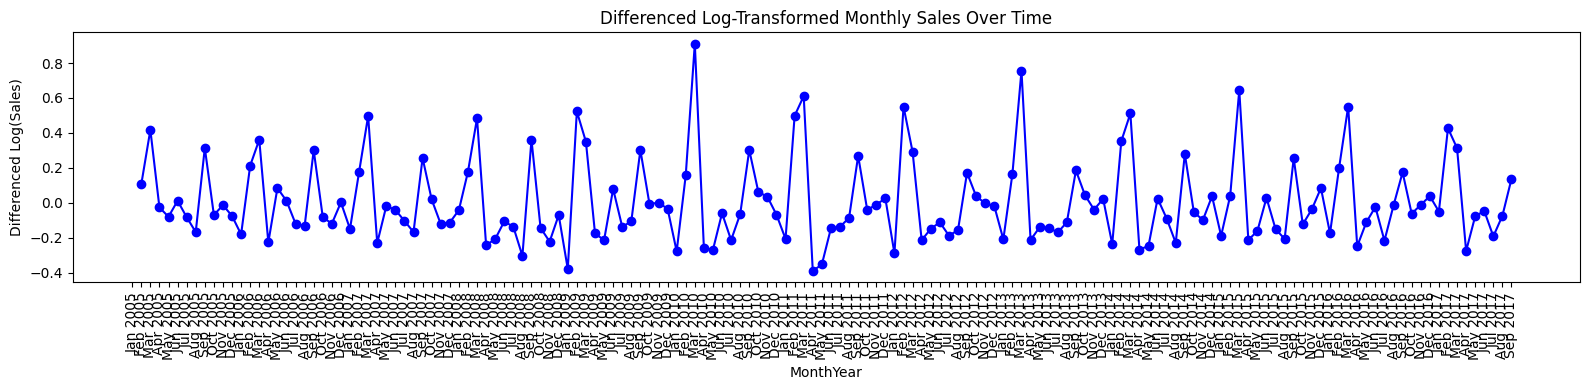

In [ ]:
# Create a line plot of the differenced log-transformed series
plt.figure(figsize=(16, 4))
plt.plot(df_ts['MonthYear'], df_ts['Sales_log_diff'], marker='o', linestyle='-', color='b')

# Customize the x-axis labels
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('MonthYear')
plt.ylabel('Differenced Log(Sales)')
plt.title('Differenced Log-Transformed Monthly Sales Over Time')

# Show the plot
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
df_ts['Sales_log_diff'].describe()

count    152.000000
mean       0.005943
std        0.240830
min       -0.388194
25%       -0.157247
50%       -0.056518
75%        0.090624
max        0.910431
Name: Sales_log_diff, dtype: float64

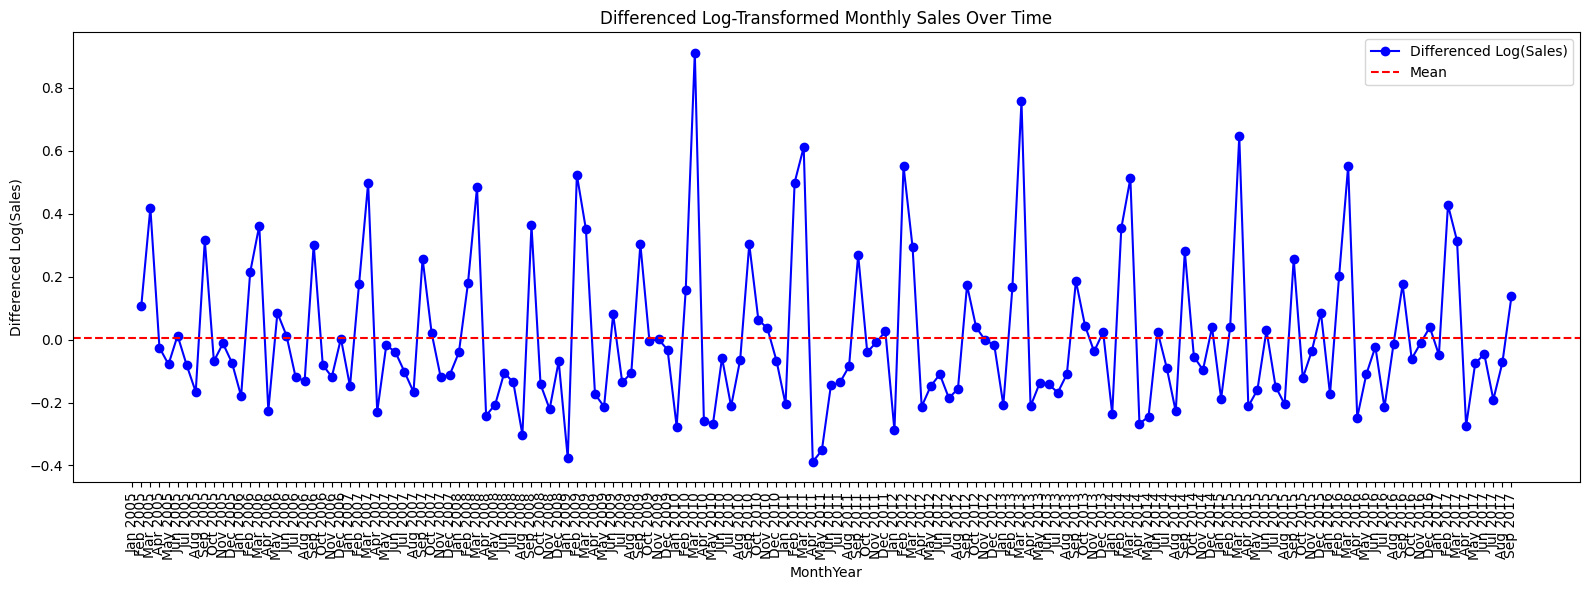

In [ ]:
#plotting with mean line

mean_sales_diff = df_ts['Sales_log_diff'].mean() # Calculate the mean of the differenced log-transformed series

# Create a line plot of the differenced log-transformed series
plt.figure(figsize=(16, 6))
plt.plot(df_ts['MonthYear'], df_ts['Sales_log_diff'], marker='o', linestyle='-', color='b', label='Differenced Log(Sales)')

# Plot the mean line
plt.axhline(mean_sales_diff, color='r', linestyle='--', label='Mean')

# Customize the x-axis labels
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('MonthYear')
plt.ylabel('Differenced Log(Sales)')
plt.title('Differenced Log-Transformed Monthly Sales Over Time')

# Show a legend with labels
plt.legend()

# Show the plot
plt.grid(False)
plt.tight_layout()
plt.show()


# **Seasonal Differencing**

In [ ]:
seasonal_diff_lag = 12
df_ts['Seasonal_Diff'] = df_ts['Sales_log_diff'].diff(seasonal_diff_lag)

# Removing missing values created by seasonal differencing
df_ts['Seasonal_Diff'].dropna(inplace=True)

<ipython-input-11-68d041d4cbf7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Seasonal_Diff'] = df_ts['Sales_log_diff'].diff(seasonal_diff_lag)
<ipython-input-11-68d041d4cbf7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Seasonal_Diff'].dropna(inplace=True)


Text(0.5, 1.0, 'Seasonal Differences in Monthly Sales Over Time')

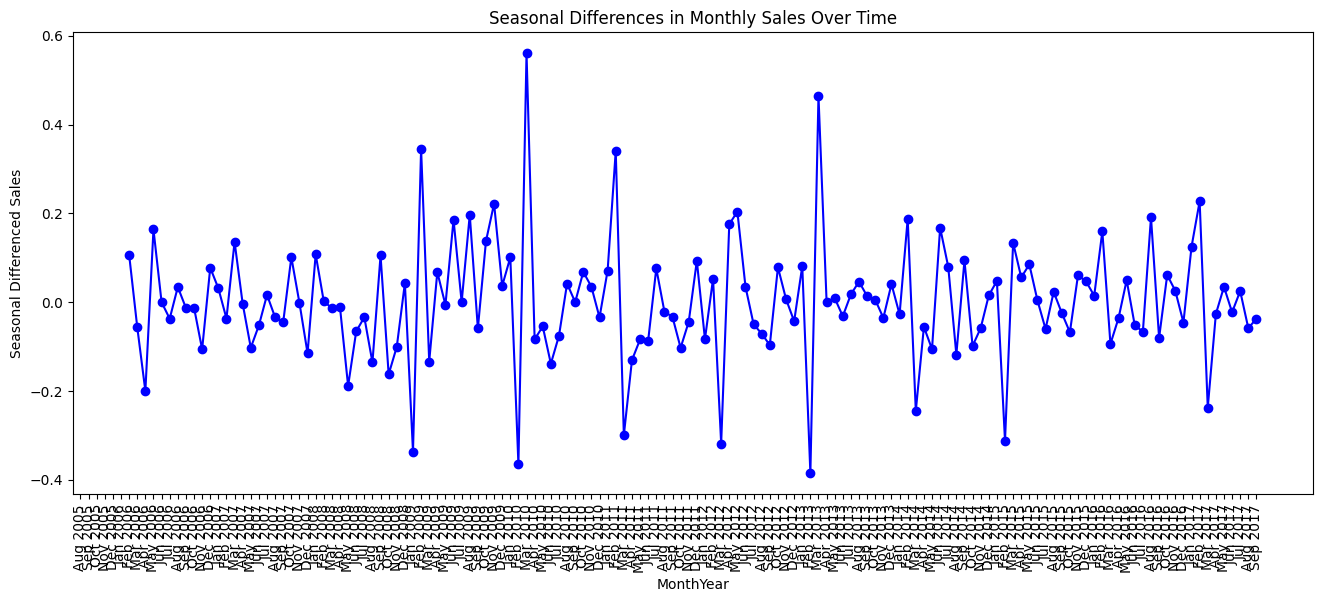

In [ ]:
# Create a line plot of the differenced log-transformed series
plt.figure(figsize=(16, 6))
plt.plot(df_ts['MonthYear'], df_ts['Seasonal_Diff'], marker='o', linestyle='-', color='b', label='Differenced Log(Sales)')

plt.xticks(rotation=90)
plt.xlabel('MonthYear')
plt.ylabel('Seasonal Differenced Sales')
plt.title('Seasonal Differences in Monthly Sales Over Time')

In [ ]:
df_ts['Seasonal_Diff'].describe()

count    140.000000
mean      -0.000202
std        0.136607
min       -0.385291
25%       -0.061753
50%       -0.002685
75%        0.062832
max        0.560520
Name: Seasonal_Diff, dtype: float64

In [ ]:
df_ts.head(20)

,MonthYear,Sales,Sales_log,Sales_log_diff,Seasonal_Diff
0,Jan 2005,10827,9.289798,NaN,NaN
1,Feb 2005,12049,9.396737,0.106939,NaN
2,Mar 2005,18298,9.814547,0.417810,NaN
3,Apr 2005,17834,9.788862,-0.025685,NaN
4,May 2005,16480,9.709903,-0.078959,NaN
5,Jun 2005,16690,9.722565,0.012662,NaN
6,Jul 2005,15389,9.641408,-0.081157,NaN
7,Aug 2005,13031,9.475086,-0.166322,NaN
8,Sep 2005,17849,9.789703,0.314616,NaN
9,Oct 2005,16662,9.720886,-0.068817,NaN


In [ ]:
Seasonal_ts = df_ts['Seasonal_Diff']
Seasonal_ts

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
148    0.034442
149   -0.022830
150    0.024844
151   -0.058599
152   -0.037279
Name: Seasonal_Diff, Length: 153, dtype: float64

In [ ]:
Seasonal_ts.dropna(inplace=True)
Seasonal_ts

<ipython-input-13-8727eaca3487>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Seasonal_ts.dropna(inplace=True)


13     0.106524
14    -0.056433
15    -0.200107
16     0.163615
17    -0.000101
         ...   
148    0.034442
149   -0.022830
150    0.024844
151   -0.058599
152   -0.037279
Name: Seasonal_Diff, Length: 140, dtype: float64

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

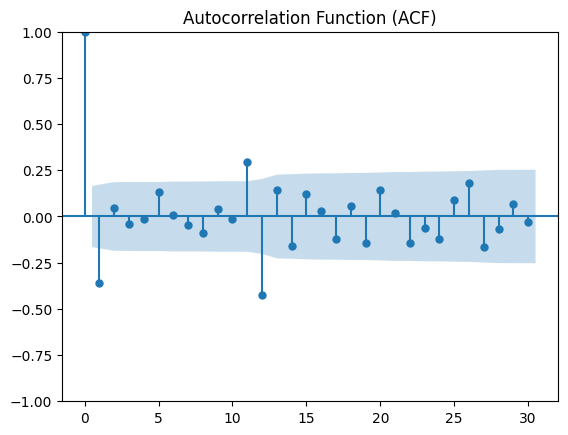

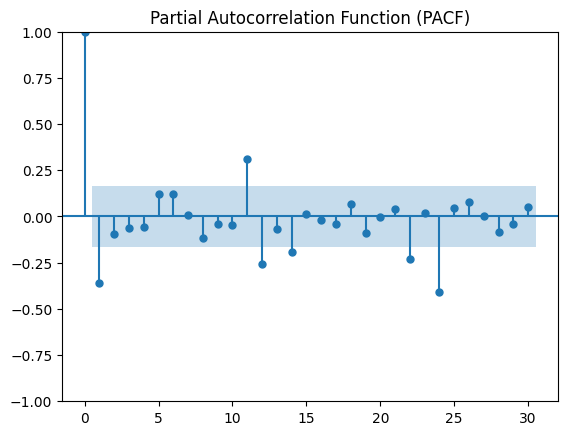

In [ ]:
plot_acf(Seasonal_ts, lags = 30)
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plot_pacf(Seasonal_ts, lags = 30)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

Seasonal = df_ts['Seasonal_Diff']
Seasonal_Diff_cleaned = df_ts['Seasonal_Diff'].dropna()

result_transformed = adfuller(Seasonal_Diff_cleaned)

adf_statistic2 = result_transformed[0]
p_value2 = result_transformed[1]
critical_values2 = result_transformed[4]

print(f'ADF Statistic: {adf_statistic2}')
print(f'p-value: {p_value2}')
print('Critical Values:')
for key, value in critical_values2.items():
    print(f'   {key}: {value}')

# Interpret the results
if p_value2 < 0.05:
    print('The time series is likely stationary (reject the null hypothesis).')
else:
    print('The time series is likely non-stationary (fail to reject the null hypothesis).')

ADF Statistic: -3.8666532392439517
p-value: 0.0022944380374154637
Critical Values:
   1%: -3.4833462346078936
   5%: -2.8847655969877666
   10%: -2.5791564575459813
The time series is likely stationary (reject the null hypothesis).
